In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import Rbf

# --- 1. DATA PREPARATION ---
df = pd.read_excel('Dataset/Vikings_aDNA.xlsx')
z_cols = [col for col in df.columns if col.startswith('Z_')]

# Calculate Reference (Average Iceland Viking)
ref_viking = df[df['CultureID'] == 1000][z_cols].mean()
# print(ref_viking)
# Calculate Euclidean Distance for everyone
def get_dist(row):
    return np.sqrt(np.sum((row[z_cols] - ref_viking)**2))

df['Genetic_Distance'] = df.apply(get_dist, axis=1)

# --- 2. THE PLOTTING FUNCTION (Simpler Version) ---
def plot_viking_bin(df_subset:pd.DataFrame, time_label:int)->None:
    # Aggregate data by location (Average distance per site)
    site_data = df_subset.groupby(['Lat', 'Long'])['Genetic_Distance'].mean().reset_index()
    
    lons = site_data['Long'].values
    lats = site_data['Lat'].values
    vals = site_data['Genetic_Distance'].values

    # SHAPE ASSERTION: Ensure every Lat/Long has exactly one value
    assert lons.shape == lats.shape == vals.shape, f"Data mismatch! Lons:{lons.shape}, Lats:{lats.shape}, Vals:{vals.shape}"
    
    if len(site_data) < 3:
        print(f"  Skipping {time_label}: Too few data points.")
        return

    # Create a grid for the heatmap
    # We make the grid slightly LARGER than our zoom so the edges are hidden
    grid_lon, grid_lat = np.mgrid[-60:50:200j, 30:80:200j]

    # Calculate the "Heat"
    rbf = Rbf(lons, lats, vals, function='multiquadric', smooth=0.1)
    z_mesh :np.ndarray= rbf(grid_lon, grid_lat)
    fil = z_mesh > 1
    z_mesh_fil = z_mesh.copy()
    z_mesh_fil[fil] = np.nan
    # z_known = rbf(lons,lats)
    # print("z_og",vals)
    # print("z_nown",z_known)

    # --- 3. THE "SANDWICH" LAYERING ---
    fig = plt.figure(figsize=(10, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # ZOOM: This "crops" the rectangular edges of the heatmap
    ax.set_extent([-50, 40, 35, 74], crs=ccrs.PlateCarree())

    # LAYER 1 (Bottom): The Heatmap
    # extend='both' helps smooth the color transition at the boundaries
    color_levels = np.linspace(0, 1, 51)
    heatmap = ax.contourf(grid_lon, grid_lat, z_mesh_fil, vmin=0, vmax=1, levels=color_levels, 
                    cmap='jet', alpha=0.7, zorder=1)

    # LAYER 2 (Middle): The Ocean Mask
    # This covers the rectangular "heat" that falls in the sea
    ax.add_feature(cfeature.LAND, facecolor='none', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='cornflowerblue', zorder=2)

    # LAYER 3 (Top): Geographical details
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.4, zorder=3)

    # LAYER 4 (Top): The actual samples as dots
    ax.scatter(lons, lats, c=vals, cmap='jet', edgecolors='black', s=40, zorder=4, vmin=0, vmax=1)

    cbar = plt.colorbar(heatmap, orientation='horizontal', pad=0.05)
    cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]) # Keep the labels consistent
    cbar.set_label('Genetic Distance (0 = Identical to Iceland Reference)')
    plt.title(f"Viking Genetic Reach: {time_label - 50} -  {time_label + 50}")
    plt.savefig(f'heatmap_{time_label}.png')
    plt.close()

# --- 4. LOOP THROUGH TIME BINS ---
df['Time_Bin'] = (df['Mean date (BP)'] // 100) * 100 + 50
for t in sorted(df['Time_Bin'].unique()):
    # print(t)
    # good: get all rows for this time bin
    current_bin_data = df[df['Time_Bin'] == t]
    plot_viking_bin(current_bin_data, int(1950 - t))

  Skipping 1700: Too few data points.
  Skipping 1600: Too few data points.
  Skipping 1300: Too few data points.
  Skipping 400: Too few data points.
  Skipping 100: Too few data points.
  Skipping 0: Too few data points.
  Skipping -2400: Too few data points.


700
700
705
710
715
720
725
730
735
740
745
750
755
760
765
770
775
780
785
790
795
800
805
810
815
820
825
830
835
840
845
850
855
860
865
870
875
880
885
890
895
900
905
910
915
920
925
930
935
940
945
950
955
960
965
970
975
980
985
990
995
1000
1005
1010
1015
1020
1025
1030
1035
1040
1045
1050
1055
1060
1065
1070
1075
1080
1085
1090
1095
1100
1105
1110
1115
1120
1125
1130
1135
1140
1145
1150
1155
1160
1165
1170
1175
1180
1185
1190
1195
700


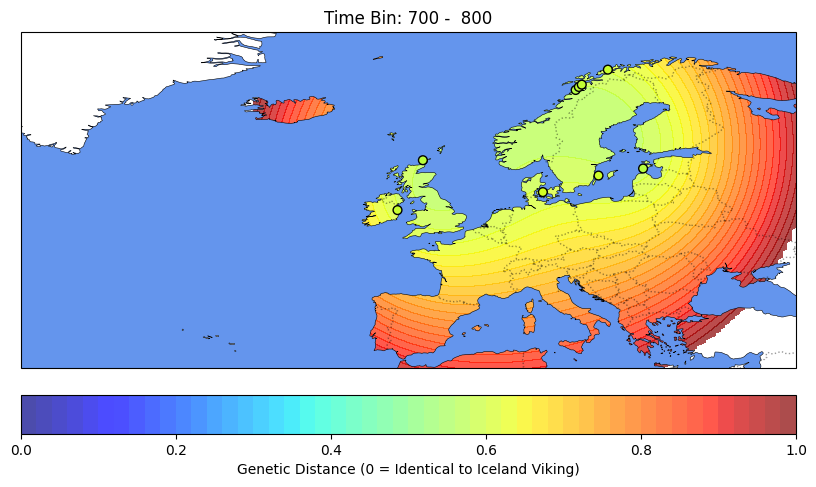

In [52]:
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import Rbf

# --- 1. DATA PREPARATION ---
df = pd.read_excel('Dataset/Vikings_aDNA.xlsx')
z_cols = [col for col in df.columns if col.startswith('Z_')]

# Calculate Reference (Average Iceland Viking)
ref_viking = df[df['CultureID'] == 1000][z_cols].mean()
# print(ref_viking)
# Calculate Euclidean Distance for everyone
def get_dist(row):
    return np.sqrt(np.sum((row[z_cols] - ref_viking)**2))

df['Genetic_Distance'] = df.apply(get_dist, axis=1)

# --- 2. THE PLOTTING FUNCTION (Simpler Version) ---
def plot_viking_bin(df_subset:pd.DataFrame, time_label:int)->None:
    print (time_label)
    # Aggregate data by location (Average distance per site)
    site_data = df_subset.groupby(['Lat', 'Long'])['Genetic_Distance'].mean().reset_index()
    
    lons = site_data['Long'].values
    lats = site_data['Lat'].values
    vals = site_data['Genetic_Distance'].values

    # SHAPE ASSERTION: Ensure every Lat/Long has exactly one value
    assert lons.shape == lats.shape == vals.shape, f"Data mismatch! Lons:{lons.shape}, Lats:{lats.shape}, Vals:{vals.shape}"
    
    if len(site_data) < 3:
        print(f"  Skipping {time_label}: Too few data points.")
        return

    # Create a grid for the heatmap
    # We make the grid slightly LARGER than our zoom so the edges are hidden
    grid_lon, grid_lat = np.mgrid[-60:50:200j, 30:80:200j]

    # Calculate the "Heat"
    rbf = Rbf(lons, lats, vals, function='multiquadric', smooth=0.1)
    z_mesh :np.ndarray= rbf(grid_lon, grid_lat)
    fil = z_mesh > 1
    z_mesh_fil = z_mesh.copy()
    z_mesh_fil[fil] = np.nan
    # z_known = rbf(lons,lats)
    # print("z_og",vals)
    # print("z_nown",z_known)

    # --- 3. THE "SANDWICH" LAYERING ---
    # fig = plt.figure(figsize=(10, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # ZOOM: This "crops" the rectangular edges of the heatmap
    ax.set_extent([-50, 40, 35, 74], crs=ccrs.PlateCarree())

    # LAYER 1 (Bottom): The Heatmap
    # extend='both' helps smooth the color transition at the boundaries
    color_levels = np.linspace(0, 1, 51)
    heatmap = ax.contourf(grid_lon, grid_lat, z_mesh_fil, vmin=0, vmax=1, levels=color_levels, 
                    cmap='jet', alpha=0.7, zorder=1)

    # LAYER 2 (Middle): The Ocean Mask
    # This covers the rectangular "heat" that falls in the sea
    ax.add_feature(cfeature.LAND, facecolor='none', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='cornflowerblue', zorder=2)

    # LAYER 3 (Top): Geographical details
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.4, zorder=3)

    # LAYER 4 (Top): The actual samples as dots
    ax.scatter(lons, lats, c=vals, cmap='jet', edgecolors='black', s=40, zorder=4, vmin=0, vmax=1)

    cbar = plt.colorbar(heatmap, orientation='horizontal', pad=0.05)
    cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]) # Keep the labels consistent
    cbar.set_label('Genetic Distance (0 = Identical to Iceland Viking)')
    plt.title(f"Time Bin: {time_label} -  {time_label + 100}")
    # plt.savefig(f'heatmap_{time_label}.png')
    return(fig,)

# --- 4. LOOP THROUGH TIME BINS ---
# df['Time_Bin'] = (df['Mean date (BP)'] // 100) * 100 + 50

# fig, ax = plt.subplots()
fig = plt.figure(figsize=(10, 7))
def update(t):
    fig.clear()# Clear the old map
    subset = df[(df['Mean date (BP)'] >= (t - 100)) & (t >= df['Mean date (BP)'])]
    # print(t)
    plot_viking_bin(subset, int(1950 - t))

ani = FuncAnimation(fig, update, frames=range(1250, 750, -5), repeat=False)
# ani.save('viking_migration.mp4', fps=10)
ani.save('viking_migration.gif', fps=10)

In [35]:
list(range(5, 3, -1))

[5, 4]

In [ ]:
# 1. Prepare 3D Data (Long, Lat, Time)
# Scale Time BP down (e.g. divide by 100) so its 'weight' matches Lat/Long
lons = df['Long'].values
lats = df['Lat'].values
times = df['Mean date (BP)'].values / 100 
vals = df['Distance'].values

# 2. Create ONE 3D RBF for the whole project
# This 'learns' the movement patterns over time
rbf_3d = Rbf(lons, lats, times, vals, function='multiquadric', smooth=0.1)

# 3. Setup the Grid
grid_lon, grid_lat = np.mgrid[-25:45:200j, 35:75:200j]

def update(current_time_bp):
    fig.clf()
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Slice the 3D model at the CURRENT time
    # We provide the grid (X, Y) and a constant T
    t_constant = current_time_bp / 100
    z_mesh = rbf_3d(grid_lon, grid_lat, np.full_like(grid_lon, t_constant))
    z_mesh = np.clip(z_mesh, 0, 1)

    # ... Plotting layers (Ocean, Coast, Heatmap) ...
    ax.contourf(grid_lon, grid_lat, z_mesh, levels=np.linspace(0,1,51), ...)
    
    # Optional: Plot only points near this time for reference
    # points = df[abs(df['Mean date (BP)'] - current_time_bp) < 50]

700
700
700
700
705
705
710
710
715
715
720
720
725
725
730
730
735
735
740
740
745
745
750
750
755
755
760
760
765
765
770
770
775
775
780
780
785
785
790
790
795
795
800
800
805
805
810
810
815
815
820
820
825
825
830
830
835
835
840
840
845
845
850
850
855
855
860
860
865
865
870
870
875
875
880
880
885
885
890
890
895
895
900
900
905
905
910
910
915
915
920
920
925
925
930
930
935
935
940
940
945
945
950
950
955
955
960
960
965
965
970
970
975
975
980
980
985
985
990
990
995
995
1000
1000
1005
1005
1010
1010
1015
1015
1020
1020
1025
1025
1030
1030
1035
1035
1040
1040
1045
1045
1050
1050
1055
1055
1060
1060
1065
1065
1070
1070
1075
1075
1080
1080
1085
1085
1090
1090
1095
1095
1100
1100
1105
1105
1110
1110
1115
1115
1120
1120
1125
1125
1130
1130
1135
1135
1140
1140
1145
1145
1150
1150
1155
1155
1160
1160
1165
1165
1170
1170
1175
1175
1180
1180
1185
1185
1190
1190
1195
1195
700
700


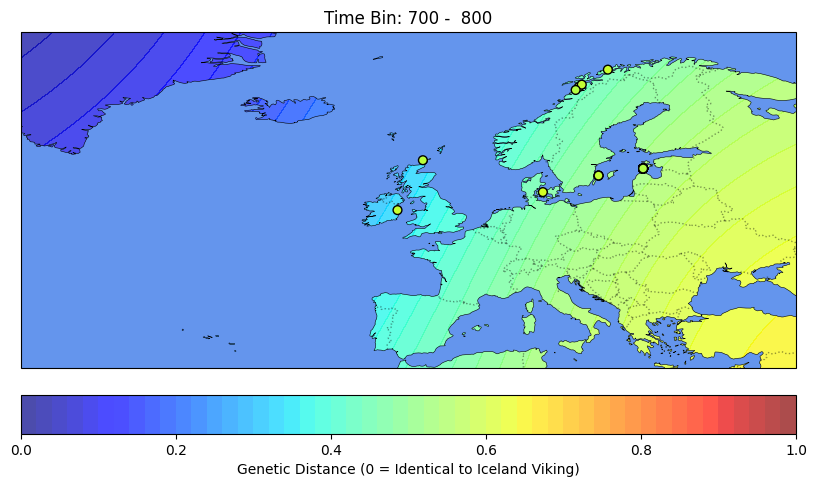

In [54]:
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import Rbf

# --- 1. DATA PREPARATION ---
df = pd.read_excel('Dataset/Vikings_aDNA.xlsx')
z_cols = [col for col in df.columns if col.startswith('Z_')]

# Calculate Reference (Average Iceland Viking)
ref_viking = df[df['CultureID'] == 1000][z_cols].mean()
# print(ref_viking)
# Calculate Euclidean Distance for everyone
def get_dist(row):
    return np.sqrt(np.sum((row[z_cols] - ref_viking)**2))

df['Genetic_Distance'] = df.apply(get_dist, axis=1)

times = df['Mean date (BP)'].values
lons = df['Long'].values
lats = df['Lat'].values
vals = df['Genetic_Distance'].values

# Create a grid for the heatmap
# We make the grid slightly LARGER than our zoom so the edges are hidden
grid_lon, grid_lat = np.mgrid[-60:50:200j, 30:80:200j]

# Calculate the "Heat"
rbf_3d = Rbf(lons, lats, times, vals, function='multiquadric', smooth=0.05)

# --- 2. THE PLOTTING FUNCTION (Simpler Version) ---
def plot_viking_bin(df_subset:pd.DataFrame, time_label:int)->None:
    print (time_label)
    # Aggregate data by location (Average distance per site)
    # print(site_data)

    lons_sub = df_subset['Long'].values
    lats_sub = df_subset['Lat'].values
    vals_sub = df_subset['Genetic_Distance'].values
    
    if len(df_subset) < 3:
        print(f"  Skipping {time_label}: Too few data points.")
        return

    # --- 3. THE "SANDWICH" LAYERING ---
    # fig = plt.figure(figsize=(10, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # ZOOM: This "crops" the rectangular edges of the heatmap
    ax.set_extent([-50, 40, 35, 74], crs=ccrs.PlateCarree())

    t_constant = time_label
    print(t_constant)
    z_mesh = rbf_3d(grid_lon, grid_lat, np.full_like(grid_lon, t_constant))
    z_mesh = np.clip(z_mesh, 0, 1)
    # z_known = rbf(lons,lats)
    # print(z_mesh)
    # print("z_nown",z_known)

    # LAYER 1 (Bottom): The Heatmap
    # extend='both' helps smooth the color transition at the boundaries
    color_levels = np.linspace(0, 1, 51)
    heatmap = ax.contourf(grid_lon, grid_lat, z_mesh, levels=color_levels, 
                    cmap='jet', alpha=0.7, zorder=1)

    # LAYER 2 (Middle): The Ocean Mask
    # This covers the rectangular "heat" that falls in the sea
    ax.add_feature(cfeature.LAND, facecolor='none', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='cornflowerblue', zorder=2)

    # LAYER 3 (Top): Geographical details
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.4, zorder=3)

    # LAYER 4 (Top): The actual samples as dots
    ax.scatter(lons_sub, lats_sub, c=vals_sub, cmap='jet', edgecolors='black', s=40, zorder=4, vmin=0, vmax=1)

    cbar = plt.colorbar(heatmap, orientation='horizontal', pad=0.05)
    cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]) # Keep the labels consistent
    cbar.set_label('Genetic Distance (0 = Identical to Iceland Viking)')
    plt.title(f"Time Bin: {time_label} -  {time_label + 100}")
    # plt.savefig(f'heatmap_{time_label}.png')
    return(fig,)

# --- 4. LOOP THROUGH TIME BINS ---
# df['Time_Bin'] = (df['Mean date (BP)'] // 100) * 100 + 50

# fig, ax = plt.subplots()
fig = plt.figure(figsize=(10, 7))
def update(t):
    fig.clear()# Clear the old map
    subset = df[(df['Mean date (BP)'] >= (t - 100)) & (t >= df['Mean date (BP)'])]
    # print(t)
    plot_viking_bin(subset, int(1950 - t))

ani = FuncAnimation(fig, update, frames=range(1250, 750, -5), repeat=False)
ani.save('viking_migration_3drbf.gif', fps=10)

In [39]:
print(vals)

[0.0302098  0.0915603  0.03164241 0.08533599 0.05302202 0.07402436
 0.13377983 0.05920573 0.06972901 0.11851483 0.18933222 0.08681529
 0.05494047 0.04803904 0.03676995 0.01481474 0.14950038 0.03398307
 0.12621871 0.03258725 0.02239674 0.08781223 0.0407792  0.05835231
 0.03376127 0.04969915 0.04362984 0.58401213 0.593542   0.59228553
 0.58916597 0.5923669  0.5906539  0.58222535 0.57549298 0.56690624
 0.56139566 0.56875678 0.57771664 0.58070945 0.59046384 0.58320855
 0.54942436 0.52741794 0.53560846 0.47604897 0.58986303 0.5606974
 0.56905196 0.58347313 0.5957297  0.59782079 0.58529307 0.59147484
 0.56290049 0.58640141 0.58517394 0.55096412 0.59662941 0.59104857
 0.5877638  0.57701504 0.57438112 0.58563559 0.56360348 0.52263849
 0.59704911 0.5821109  0.58788496 0.60559139 0.58451444 0.5887174
 0.60870499 0.5815341  0.58843368 0.59979863 0.576785   0.61814866
 0.58224459 0.57512547 0.59095818 0.59306149 0.57907032 0.62206235
 0.56611803 0.69787292 0.59277922 0.58891675 0.58571188 0.585758